# ILUSTR 1 — Postać kanoniczna Ax=b: przykład z macierzą obrotu

Ten notebook pokazuje, skąd w praktyce biorą się układy równań liniowych — na konkretnym, wizualnym przykładzie z grafiki komputerowej/CAD, a nie na abstrakcyjnych liczbach.

**Zagadnienie.** Punkt w przestrzeni 3D obracamy wokół osi OY o kąt Θ. Macierz obrotu ma postać:

$$
R_y(\Theta) =
\begin{bmatrix}
\cos\Theta & 0 & \sin\Theta \\
0 & 1 & 0 \\
-\sin\Theta & 0 & \cos\Theta
\end{bmatrix}
$$

Jeśli znamy punkt początkowy $\mathbf{x}$, to punkt po obrocie liczymy wprost: $\mathbf{y} = R_y(\Theta)\,\mathbf{x}$ — samo mnożenie macierzy przez wektor, żadnego układu równań nie trzeba rozwiązywać.

**Ale** w wielu zastosowaniach mamy dane odwrotne: znamy punkt **po** obrocie $\mathbf{y}$ i kąt $\Theta$, a szukamy punktu **przed** obrotem $\mathbf{x}$. To już jest układ równań liniowych w postaci kanonicznej $A\mathbf{x} = \mathbf{b}$, gdzie $A = R_y(\Theta)$ jest macierzą znaną i ustaloną, a $\mathbf{b} = \mathbf{y}$.

In [1]:
import numpy as np

def rotation_y(theta):
    # Macierz obrotu wokół osi OY o kąt theta (w radianach) -- wprost ze wzoru z wykładu.
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c],
    ])

theta = np.deg2rad(40)   # kąt obrotu: 40 stopni
A = rotation_y(theta)    # macierz A jest teraz ustalona -- to jest kluczowe w dalszej części notebooka

# Punkt PO obrocie (dany, np. zmierzony/zaobserwowany)
y_znany = np.array([2.0, 1.0, 0.5])

# Szukamy punktu PRZED obrotem: rozwiązujemy A @ x = y_znany
x_start = np.linalg.solve(A, y_znany)

print("Punkt po obrocie (dany):      ", y_znany.round(4))
print("Odtworzony punkt przed obrotem:", x_start.round(4))

# Kontrola: obrócenie odtworzonego punktu powinno dać z powrotem y_znany
print("Sprawdzamy (A @ x_start):       ", (A @ x_start).round(4))

Punkt po obrocie (dany):       [2.  1.  0.5]
Odtworzony punkt przed obrotem: [1.2107 1.     1.6686]
Sprawdzamy (A @ x_start):        [2.  1.  0.5]


## Wiele punktów naraz — skąd biorą się duże układy równań

W praktyce niemal nigdy nie obracamy pojedynczego punktu. Weźmy konkretny przykład z grafiki komputerowej: mamy obraz $8\times 8$ pikseli — siatkę 64 punktów leżących w płaszczyźnie ekranu — i chcemy obrócić **cały obraz naraz** o ten sam kąt Θ.

Zamiast pisać pętlę i wołać `solve` 64 razy (raz na piksel), możemy skleić wszystkie 64 punkty w jedną macierz $B$ (o wymiarach $3\times 64$, gdzie każda kolumna to jeden piksel) i rozwiązać **jeden** układ $AX=B$ z wieloma prawymi stronami naraz — `numpy` obsługuje to jednym wywołaniem `solve`.

To jest właśnie moment, w którym z pojedynczego, małego równania (3 niewiadome) w praktyce robi się **duży układ** — bo prawdziwe zadania (obrazy, siatki CAD, chmury punktów ze skanera 3D) niemal zawsze wymagają rozwiązania tego samego układu dla wielu wektorów $b$ naraz, a nie dla jednego.

In [2]:
# Obraz 8x8 pikseli jako siatka punktów w płaszczyźnie ekranu (y=0).
# np.meshgrid buduje dwie tablice 8x8 ze współrzędnymi x i z każdego piksela siatki;
# .ravel() spłaszcza je do wektorów długości 64 (jeden numer na piksel).
n = 8
xs, zs = np.meshgrid(np.arange(n), np.arange(n))

# Sklejamy współrzędne x, y (=0) i z w jedną macierz B o wymiarach (3, 64) --
# każda KOLUMNA to jeden piksel PO obrocie (czyli jeden wektor b z układu A x = b).
B = np.vstack([xs.ravel(), np.zeros(n * n), zs.ravel()])

# Zamiast pętli "for piksel in obraz: solve(...)" -- jedno wywołanie solve dla
# całej macierzy B naraz. numpy rozwiązuje wtedy 64 układy (po jednym na kolumnę),
# ale liczy je razem, bez pętli w kodzie Pythona.
X_obraz = np.linalg.solve(A, B)   # (3, 64) -- 64 rozwiązania w jednym wywołaniu

print(f"Liczba pikseli obrazu:            {B.shape[1]}")
print(f"Kształt macierzy prawych stron B: {B.shape}")
print(f"Kształt rozwiązania X:            {X_obraz.shape}")
print("Kontrola (A @ X_obraz == B):     ", np.allclose(A @ X_obraz, B))

Liczba pikseli obrazu:            64
Kształt macierzy prawych stron B: (3, 64)
Kształt rozwiązania X:            (3, 64)
Kontrola (A @ X_obraz == B):      True


### Co naprawdę kryje się pod jednym wywołaniem `solve(A, B)`?

Formalnie, obrócenie 64 niezależnych punktów tym samym kątem Θ to tak naprawdę **jeden wielki układ** $A_{\text{big}}\,\mathbf{x}_{\text{big}} = \mathbf{b}_{\text{big}}$, gdzie $\mathbf{x}_{\text{big}}$ i $\mathbf{b}_{\text{big}}$ to współrzędne wszystkich 64 punktów sklejone w jeden długi wektor (64 punkty × 3 współrzędne = 192 niewiadome), a $A_{\text{big}}$ to macierz **blokowo-diagonalna**: na przekątnej 64 kopie tej samej macierzy $A$ (po jednej na punkt), a wszędzie indziej — **same zera**.

Te zera poza blokami nie są przypadkiem. Oznaczają, że współrzędne punktu $i$ **po** obrocie zależą wyłącznie od współrzędnych punktu $i$ **przed** obrotem, a nie od żadnego innego punktu. Gdyby w macierzy pojawiła się niezerowa wartość poza blokiem punktu $i$, oznaczałoby to, że ruch tego piksela zależy też od położenia jakiegoś innego piksela — a w tym zadaniu piksele obracają się całkowicie niezależnie od siebie. Zobaczmy to najpierw na małym przykładzie (4 punkty), a potem na całym obrazie 8×8.

Struktura macierzy "skompresowanej" dla 4 punktów naraz


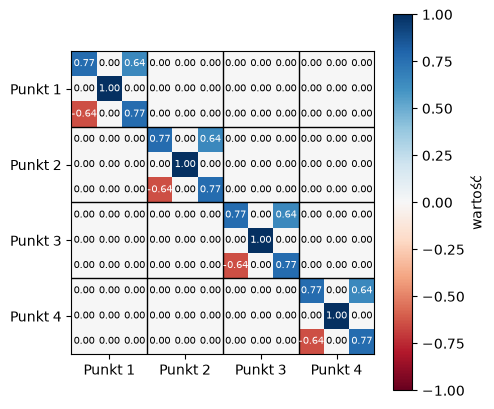

Każdy blok na przekątnej to dokładnie ta sama macierz A (rozmiar 3x3).
Poza blokami macierz ma same zera: 20 niezerowych elementów spośród 144 -- reszta to zera, bo punkty są od siebie niezależne.


In [3]:
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

# Male, czytelne demo -- bierzemy tylko 4 pierwsze piksele, zeby macierz zmiescila sie na ekranie.
# block_diag sklada podane macierze "po przekatnej": powstaje macierz (3*k, 3*k),
# ktora ma k kopii macierzy A na przekatnej, a wszedzie indziej same zera.
k = 4
A_demo = block_diag(*([A] * k))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(A_demo, cmap='RdBu', vmin=-1, vmax=1)

# Rysujemy czarne linie na granicach bloków 3x3 -- kazdy blok odpowiada jednemu punktowi
for granica in range(1, k):
    ax.axhline(granica * 3 - 0.5, color='black', linewidth=1)
    ax.axvline(granica * 3 - 0.5, color='black', linewidth=1)

# Dopisujemy wartości liczbowe wprost na wykresie -- macierz widać wtedy nie tylko
# jako kolory, ale też "zapisaną w tekście", liczba po liczbie.
for i in range(A_demo.shape[0]):
    for j in range(A_demo.shape[1]):
        wartosc = A_demo[i, j]
        kolor_tekstu = 'white' if abs(wartosc) > 0.6 else 'black'
        ax.text(j, i, f'{wartosc:.2f}', ha='center', va='center', fontsize=7, color=kolor_tekstu)

print(f'Struktura macierzy "skompresowanej" dla {k} punktów naraz')
ax.set_xticks(np.arange(1, 3 * k, 3))
ax.set_xticklabels([f'Punkt {i + 1}' for i in range(k)])
ax.set_yticks(np.arange(1, 3 * k, 3))
ax.set_yticklabels([f'Punkt {i + 1}' for i in range(k)])
# ax.set_title(f'Struktura macierzy "skompresowanej" dla {k} punktów naraz')
plt.colorbar(im, ax=ax, shrink=0.8, label='wartość')
plt.tight_layout()
plt.show()

print(f"Każdy blok na przekątnej to dokładnie ta sama macierz A (rozmiar 3x3).")
print(f"Poza blokami macierz ma same zera: {np.count_nonzero(A_demo)} niezerowych "
      f"elementów spośród {A_demo.size} -- reszta to zera, bo punkty są od siebie niezależne.")

In [4]:
# Ta sama idea, tylko dla calego obrazu 8x8 (64 punkty x 3 wspolrzedne = 192 niewiadome)
A_big = block_diag(*([A] * (n * n)))      # (192, 192) -- 64 kopie A na przekatnej, reszta zer

# B ma ksztalt (3, 64): KOLUMNY to kolejne punkty. Zeby dopasowac kolejnosc do A_big
# (gdzie blok i-ty na przekatnej odpowiada wspolrzednym i-tego punktu), potrzebujemy
# wektora "punkt po punkcie": [x1,y1,z1, x2,y2,z2, ...], a nie "wspolrzedna po
# wspolrzednej" ([x1,x2,...,x64, y1,y2,...]). Dlatego najpierw transponujemy B do
# (64, 3) -- teraz KAZDY WIERSZ to jeden punkt -- a dopiero potem splaszczamy
# .reshape(-1), ktore domyslnie sklada wiersz po wierszu ("porzadek C" w numpy).
# Bez tej transpozycji .reshape(-1) na oryginalnym B dalby zla kolejnosc.
b_big = B.T.reshape(-1)

x_big = np.linalg.solve(A_big, b_big)      # jeden uklad 192x192 zamiast 64 ukladow 3x3
X_obraz_big = x_big.reshape(n * n, 3).T    # z powrotem do ksztaltu (3, 64), zeby porownac z X_obraz

print("Zgodność z wynikiem solve(A, B) z poprzedniej sekcji:", np.allclose(X_obraz_big, X_obraz))

Zgodność z wynikiem solve(A, B) z poprzedniej sekcji: True


## Wizualizacja

Wiele punktów w przestrzeni opisuje jakiś obiekt. Najłatwiej pokazać to za pomocą obiektów geometrycznych, choć w praktyce są to matematyczne opisy fizycznych systemów. Pokazujemy dwa takie przykłady: literę „L” leżącą w płaszczyźnie $y=0$, oraz helisę nawiniętą na oś OX.

Chmura punktów **po** obrocie (dana) i odtworzona chmura punktów **przed** obrotem — powinny być względem siebie po prostu obrócone o Θ.

Zwróć uwagę na sens takiego podejścia. Wektor **b** opisuje cały obiekt (współrzędne wszystkich punktów), a macierz **A** opisuje przekształcenie całego obiektu. To elegancki i powszechnie stosowany opis w modelowaniu matematycznym.

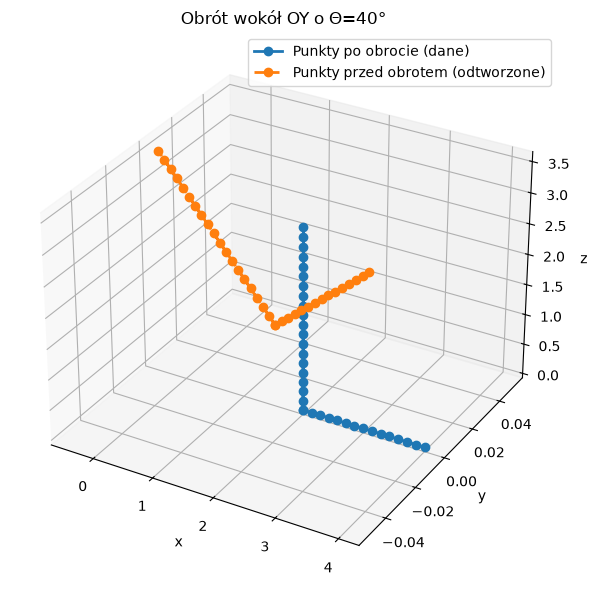

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- rejestruje projekcję 3D w matplotlib

# Kształt testowy: litera "L" leżąca w płaszczyźnie y=0 
pion = np.column_stack([np.full(20, 2.0), np.zeros(20), np.linspace(0, 3, 20)])     # pionowa kreska litery L
poziom = np.column_stack([np.linspace(2, 4, 15), np.zeros(15), np.zeros(15)])       # pozioma kreska litery L
Y_ksztalt = np.vstack([pion, poziom])            # wszystkie punkty litery L PO obrocie (dane)

# Jedno wywołanie solve z wieloma prawymi stronami naraz (tak jak w sekcji o obrazie 8x8 wyżej) --
# Y_ksztalt.T ma wymiary (3, liczba_punktów), więc każda kolumna to jeden punkt.
X_ksztalt = np.linalg.solve(A, Y_ksztalt.T).T    # punkty litery L PRZED obrotem (odtworzone)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(Y_ksztalt[:, 0], Y_ksztalt[:, 1], Y_ksztalt[:, 2], 'o-', label='Punkty po obrocie (dane)', linewidth=2)
ax.plot(X_ksztalt[:, 0], X_ksztalt[:, 1], X_ksztalt[:, 2], 'o--', label='Punkty przed obrotem (odtworzone)', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.title(f'Obrót wokół OY o Θ={np.rad2deg(theta):.0f}°')
plt.tight_layout()
plt.show()

### Drugi przykład: helisa, ale nawinięta na inną oś

Na niebiesko helisa po obrocie (dane), na pomarańczowo (linia przerywana) odtworzona helisa przed obrotem.

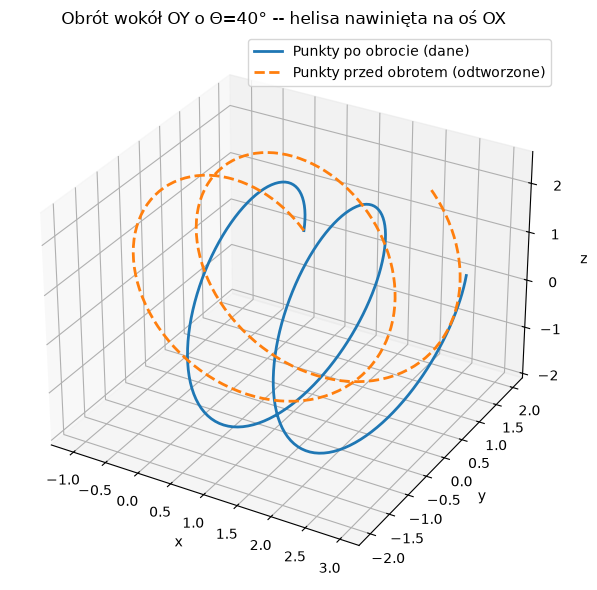

In [6]:
t = np.linspace(0, 4 * np.pi, 200)
Y_helisa = np.column_stack([t / 5, 2 * np.cos(t), 2 * np.sin(t)])   # punkty PO obrocie (dane)
X_helisa = np.linalg.solve(A, Y_helisa.T).T                          # punkty PRZED obrotem (odtworzone)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(Y_helisa[:, 0], Y_helisa[:, 1], Y_helisa[:, 2], label='Punkty po obrocie (dane)', linewidth=2)
ax.plot(X_helisa[:, 0], X_helisa[:, 1], X_helisa[:, 2], '--', label='Punkty przed obrotem (odtworzone)', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.title(f'Obrót wokół OY o Θ={np.rad2deg(theta):.0f}° -- helisa nawinięta na oś OX')
plt.tight_layout()
plt.show()

## Najważniejsze wnioski

- Układ $A\mathbf{x}=\mathbf{b}$ nie musi pochodzić z abstrakcyjnych liczb — w rzeczywistości jest modelem matematycznym jakiegoś rzeczywistego obiektu lub systemu. Tutaj wynika wprost z geometrii i opisuje obiekty geometryczne i ich przekształcenia.
- Gdy wszystkie punkty są znane z góry (np. cały obraz/siatka CAD), to podobnie opisujemy cały taki system w postaci jednego układu równań. Typowo układ równań ma tyle kolumn/wierszy ile jest elementów systemu (np. ilość punktów n) i ile jest parametrów opisujących każdy element (u nas są to trzy parametry - współrzędne punktu - stąd rozmiar macierzy to 8x8x3 = 192). Zwróć uwagę jak szybko wielkość układu "puchnie" wraz z ilością elementów i ilością parametrów którymi element jest opisany.
- Sposób rozwiązania takiego układu (nie tylko sama jego budowa) ma znaczenie dla czasu obliczeń — dla naszej małej macierzy obrotu $3\times 3$ różnice te są niewidoczne, ale stają się istotne dla dużych układów. Zajmujemy się tym w kolejnym notebooku (ILUSTR2).

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.linalg.solve(A, b)` | Rozwiązuje układ $Ax=b$; gdy $b$ jest macierzą (wiele kolumn), rozwiązuje wszystkie naraz jednym wywołaniem |
| `scipy.linalg.block_diag(A, A, ...)` | Skleja podane macierze "po przekątnej" w jedną większą macierz blokowo-diagonalną (zera poza blokami) |
| `np.column_stack([...])` / `np.vstack([...])` | Skleja wektory w macierz |
| `np.meshgrid(...)` | Generuje siatkę współrzędnych (np. pikseli obrazu) |
| `plt.imshow(M)` | Rysuje macierz jako obraz -- kolor komórki odpowiada jej wartości |
| `plt.spy(M)` | Rysuje tylko strukturę niezerowych elementów macierzy (przydatne dla dużych, rzadkich macierzy) |

## ĆWICZENIE

1. Policz $A^{-1}$ i porównaj go z transpozycją $A^{T}$ (macierz obrotu jest ortogonalna) — czy nie jest to jeszcze szybszy sposób na rozwiązanie tego konkretnego układu?